
# Linear regression: Beer-Lambert Law for Absorbance
## Chem 190/290, Spring 2026, Liang Shi


A student has done the absorption spectrum experiment, and saved the data in the text file "concentration_intensity.txt". The file has two columns: the first column is concentration, and the second is transmitted light intensity. 


In [7]:
# Bring in numpy(for numerical operations) and matplotlib.pyplot (for graphics)
import numpy as np
import matplotlib.pyplot as plt

In [8]:
%matplotlib inline

## 1. Data loading and pre-processing

In [9]:
# Load the data
data = np.loadtxt("concentration_intensity.txt")

# Split into columns
concentration = data[:, 0]
intensity = data[:, 1]

print(concentration)
print(intensity)

[0.         0.11111111 0.22222222 0.33333333 0.44444444 0.55555556
 0.66666667 0.77777778 0.88888889 1.        ]
[500.3502     240.655256   118.2739533   59.58595722  30.87329228
  16.50699498   9.14040916   5.26355926   3.16811016   2.00514134]


In [10]:
# Reference intensity (zero concentration)
I0 = intensity[concentration == 0][0]

# Compute absorbance
absorbance = -np.log10(intensity / I0)

print(absorbance)

[-0.          0.31787873  0.62638496  0.92413016  1.20969113  1.48160606
  1.73830844  1.97799456  2.1984738   2.39712909]


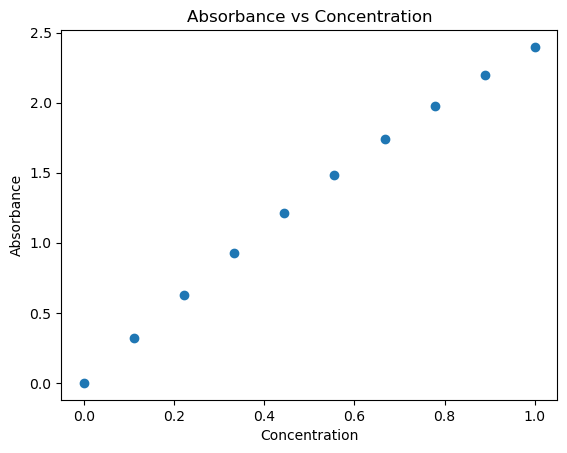

In [11]:
# Plot
plt.figure()
plt.scatter(concentration, absorbance)
plt.xlabel("Concentration")
plt.ylabel("Absorbance")
plt.title("Absorbance vs Concentration")
plt.show()

## 2. Linear Fitting using Numpy's Function

In [12]:
# (Optional but common) exclude zero concentration from the fit
mask = concentration > 0
c_fit = concentration[mask]
A_fit = absorbance[mask]

# Linear regression: A = m c + b
m, b = np.polyfit(c_fit, A_fit, 1)

print(f"Slope (m): {m}")
print(f"Intercept (b): {b}")

Slope (m): 2.350442110031
Intercept (b): 0.12437626463037531


In [13]:
# Predicted absorbance
A_pred = m * c_fit + b

# R-squared
ss_res = np.sum((A_fit - A_pred)**2)
ss_tot = np.sum((A_fit - np.mean(A_fit))**2)
r_squared = 1 - ss_res / ss_tot

print(f"R^2: {r_squared}")

R^2: 0.9954568356606366


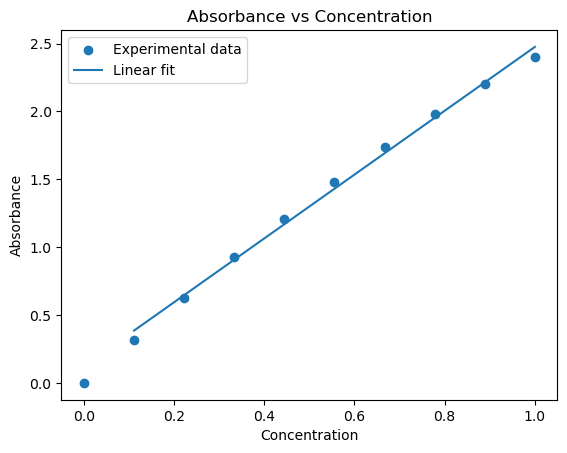

In [14]:
# Generate fitted line over the concentration range
c_line = np.linspace(c_fit.min(), c_fit.max(), 100)
A_line = m * c_line + b

# Plot
plt.figure()
plt.scatter(concentration, absorbance, label="Experimental data")
plt.plot(c_line, A_line, label="Linear fit")
plt.xlabel("Concentration")
plt.ylabel("Absorbance")
plt.title("Absorbance vs Concentration")
plt.legend()
plt.show()

## 3. Linear Regression Using Normal Equation
Data matrix:
$$ \mathbf{X} = 
\begin{pmatrix}
1 & x_1 \\
1 & x_2 \\
\cdots & \cdots \\
1 & x_m 
\end{pmatrix}
$$
Label vector
$$ \vec{y} = 
\begin{pmatrix}
y_1 \\
y_2 \\
\cdots \\
y_m 
\end{pmatrix}
$$
Coefficient vector
$$ \vec{\theta} = 
\begin{pmatrix}
\theta_0 \\
\theta_1 \\
\end{pmatrix}
$$
Master equation:
$$
\vec{\theta} = (\mathbf{X}^{T} \mathbf{X})^{-1} \mathbf{X}^T \vec{y}
$$

In [15]:
# write a code to prepare the data matrix and label vector, print them to make sure they are correct.
# please remove the zero concentration data from your data set.

In [16]:
# use the normal equation to compute theta, print theta to see if it matches the results obtained in section 2. 

## 4. Linear Regression using Gradient Descent

Let's first simplify the problem. Since there is no absorbance at zero concentration, the calibration curve is expected to go through the origin (i.e., the intercept should be 0). The linear model is then $\tilde{y} = \theta x$. In this scenario, the data matrix becomes
$$ \mathbf{X} = 
\begin{pmatrix}
x_1 \\
x_2 \\
\cdots \\
x_m 
\end{pmatrix}
$$

In [17]:
# write a code to redo the fitting with this new data matrix

Now let's use gradient descent to find the theta that minimizes the loss function.
$$
L(\theta) = \sum_{i=1}^m \left ( \tilde{y}_i - y_i \right)^2 = \sum_{i=1}^m \left ( \theta x_i - y_i \right)^2
$$

In [18]:
def loss(theta, x, y):
    return np.sum((theta * x - y) ** 2)

Compute the gradient of the loss function.
$$
\frac{dL}{d\theta} = 2 \sum_{i=1}^m \left ( \theta x_i - y_i \right) x_i
$$

In [19]:
def gradient(theta, x, y):
    return 2 * np.sum((theta * x - y) * x)

Gradient descent loop

In [20]:
def gradient_descent(x, y, alpha=0.01, n_iters=1000):
    theta = 0.0  # initial guess

    for _ in range(n_iters):
        grad = gradient(theta, x, y)
        theta -= alpha * grad

    return theta

In [21]:
# run the GD algorithm
theta = gradient_descent(X, y, alpha=0.1, n_iters=100)
print(theta)

NameError: name 'X' is not defined

In [22]:
# visualize the GD process
from matplotlib.animation import FuncAnimation

# Gradient descent with history recording
def gradient_descent_history(x, y, alpha=0.01, n_iters=100):
    theta = 0.0
    history = [theta]
    for _ in range(n_iters):
        grad = gradient(theta, x, y)
        theta -= alpha * grad
        history.append(theta)
    return history

# Run gradient descent and record theta at each step (try alpha=0.285, 0.28, 0.25, 0.1, 0.01, 0.001)
history = gradient_descent_history(X, y, alpha=0.25, n_iters=100)

# Print the last theta value
# Print the last 10 theta values
last_10_thetas = history[-10:]
print("Last 10 theta values:", last_10_thetas)

# Prepare loss curve for theta from 0 to 5
theta_vals = np.linspace(0, 5, 300)
loss_vals = [loss(t, X, y) for t in theta_vals]

# Create figure
fig, ax = plt.subplots(figsize=(8,5))
ax.plot(theta_vals, loss_vals, label='Loss function')
point, = ax.plot([], [], 'ro', label='Theta update')
ax.set_xlabel('Theta')
ax.set_ylabel('Loss')
ax.set_title('Gradient Descent Animation')
ax.legend()
ax.grid(True)

# Animation function
def update(frame):
    theta = history[frame]
    point.set_data([theta], [loss(theta, X, y)])
    return point,

# Create animation
anim = FuncAnimation(fig, update, frames=len(history), interval=100, blit=True)

# Display animation in notebook
from IPython.display import HTML
HTML(anim.to_jshtml())

NameError: name 'X' is not defined